# Conformal Prediction for Directed Graph Link Prediction

This notebook presents a **directed link prediction** framework using **split conformal prediction** on the **Wikivitals** dataset. This produce prediction sets $C(x) \subseteq \{0, 1\}$ with guaranteed coverage at a chosen confidence level (e.g., 90%).

## Key Differences from Undirected Graphs

1. **Asymmetric adjacency matrix**: $A_{ij} \neq A_{ji}$ in general
2. **Directed embeddings**: Separate source and target embeddings
3. **In-degree and out-degree**: Two distinct degree metrics per node
4. **Directed features**: Asymmetric similarity and structural features

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sknetwork.embedding import SVD
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_fscore_support

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

## 1. Mathematical Foundations

### 1.1 Directed Graph Representation

A directed graph $G = (V, E)$ consists of:
- A set of vertices $V = \{v_1, v_2, \ldots, v_n\}$
- A set of directed edges $E \subseteq V \times V$, where $(u, v) \in E$ represents an edge from $u$ to $v$

The **adjacency matrix** $A \in \{0,1\}^{n \times n}$ is defined as:

$$
A_{ij} = \begin{cases}
1 & \text{if } (v_i \to v_j) \in E \\
0 & \text{otherwise}
\end{cases}
$$

Note: $A_{ij} = 1$ does NOT imply $A_{ji} = 1$ (asymmetry).

### 1.2 Node Degree Metrics

For a directed graph, each node $v_i$ has two degree measures:

**Out-degree** (number of outgoing edges):
$$
d^{\text{out}}_i = \sum_{j=1}^{n} A_{ij}
$$

**In-degree** (number of incoming edges):
$$
d^{\text{in}}_i = \sum_{j=1}^{n} A_{ji}
$$

### 1.3 Mondrian (Label-Conditional) Split Conformal Quantiles

For each class $y \in \{0, 1\}$, define the calibration index set and count:
$$\mathcal{I}_y = \{i \in \{1,\dots,n\} : y_i = y\}, \qquad n_y = |\mathcal{I}_y|$$

Compute the finite-sample rank:
$$k_y = \lceil (n_y + 1)(1 - \alpha) \rceil$$

The quantile $q_y$ is the $k_y$-th order statistic of the class-$y$ calibration scores:
$$q_y = s^{(y)}_{(k_y)} \quad \text{where} \quad s^{(y)}_{(1)} \le s^{(y)}_{(2)} \le \cdots \le s^{(y)}_{(n_y)}$$

**Non-conformity scores** (with $p_i = P(Y=1|x_i)$):
$$s(x, 1) = 1 - p(x), \qquad s(x, 0) = p(x)$$

**Class-conditional quantiles**:
$$q_1 = (1 - p_i)_{(k_1)}, \; i \in \mathcal{I}_1, \qquad q_0 = (p_i)_{(k_0)}, \; i \in \mathcal{I}_0$$

**Probability thresholds**:
$$t_{\text{upper}} = 1 - q_1, \qquad t_{\text{lower}} = q_0$$

If $k_y > n_y$, set $q_y = \infty$ to guarantee coverage.

This ensures marginal coverage: $\mathbb{P}(Y \in C(X)) \geq 1 - \alpha$.

In [2]:
def conformal_quantile(scores, alpha):
    """
    Mondrian (label-conditional) split conformal quantile.
    
    Returns the k-th order statistic where k = ceil((n+1)(1-alpha)).
    If k > n, returns infinity to guarantee coverage.
    
    Parameters:
    -----------
    scores : array-like
        Calibration non-conformity scores for a single class
    alpha : float
        Target error rate (e.g., 0.1 for 90% coverage)
    
    Returns:
    --------
    float : The conformal quantile threshold q_y
    """
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    
    # If k > n, return infinity to ensure coverage
    if k > n:
        return np.inf
    
    # Return the k-th order statistic (k-th smallest value)
    sorted_scores = np.sort(scores)
    return sorted_scores[k - 1]  # k-1 for 0-indexed array

print("Conformal quantile function ready.")

Conformal quantile function ready.


In [3]:
# =============================================================================
# A) Efficiency metrics for prediction sets
# =============================================================================
def set_metrics(y_true, sets):
    """
    Compute efficiency metrics for conformal prediction sets.
    
    Returns only the key metrics:
    - coverage: P(y in C(x)) - the main CP validity measure
    - avg_set_size: efficiency measure (near 1 = decided, near 2 = abstaining)
    - retention: fraction decided (size==1)
    - decided_acc: accuracy conditional on not abstaining
    """
    y_true = np.asarray(y_true)
    sizes = np.array([len(s) for s in sets])
    coverage = np.mean([y in s for y, s in zip(y_true, sets)])
    avg_set_size = np.mean(sizes)
    retention = np.mean(sizes == 1)

    decided_idx = np.where(sizes == 1)[0]
    if len(decided_idx) > 0:
        y_dec = y_true[decided_idx]
        pred_dec = np.array([next(iter(sets[i])) for i in decided_idx])
        acc_dec = np.mean(pred_dec == y_dec)
    else:
        acc_dec = np.nan

    return {
        "coverage": coverage,
        "avg_set_size": avg_set_size,
        "retention": retention,
        "decided_acc": acc_dec,
    }

# =============================================================================
# B) Non-conformal abstaining baseline matched to CP retention
# =============================================================================
def baseline_sets_from_margin(p, delta):
    """Generate prediction sets using margin-based abstention."""
    sets = []
    for pi in p:
        if pi >= 0.5 + delta:
            sets.append({1})
        elif pi <= 0.5 - delta:
            sets.append({0})
        else:
            sets.append({0, 1})
    return sets

def choose_delta_to_match_retention(p_cal, target_retention):
    """Choose delta threshold to match a target retention rate."""
    conf = np.abs(p_cal - 0.5)
    q = np.quantile(conf, 1 - target_retention)
    return float(q)

# =============================================================================
# C) Risk-coverage curve + AURC
# =============================================================================
def risk_coverage_curve(y_true, p):
    """Compute risk-coverage curve for selective prediction."""
    y_true = np.asarray(y_true)
    conf = np.abs(p - 0.5)
    order = np.argsort(-conf)  # high confidence first

    risks = []
    coverages = []
    correct = ((p >= 0.5).astype(int) == y_true).astype(float)

    cum_correct = np.cumsum(correct[order])
    for k in range(1, len(y_true) + 1):
        cov = k / len(y_true)
        acc = cum_correct[k-1] / k
        risk = 1 - acc
        coverages.append(cov)
        risks.append(risk)

    return np.array(coverages), np.array(risks)

def aurc(coverages, risks):
    """Compute Area Under Risk-Coverage curve (lower is better)."""
    return float(np.trapz(risks, coverages))

# =============================================================================
# D) Calibration Split (cal1/cal2) for clean CP + baseline design
# =============================================================================
def split_calibration_indices(n_cal, frac_cal1, rng):
    """Split calibration indices into cal1 (CP thresholds) and cal2 (retention estimation)."""
    idx = rng.permutation(n_cal)
    n1 = int(np.floor(frac_cal1 * n_cal))
    cal1_idx = idx[:n1]
    cal2_idx = idx[n1:]
    return cal1_idx, cal2_idx

def cp_sets_from_thresholds(p, t_lower, t_upper, empty_policy="empty"):
    """Generate CP prediction sets from probability thresholds."""
    sets = []
    for pi in p:
        s = set()
        if pi <= t_lower:
            s.add(0)
        if pi >= t_upper:
            s.add(1)
        if len(s) == 0 and empty_policy == "abstain":
            s = {0, 1}
        sets.append(s)
    return sets

# =============================================================================
# E) Degree-bin analysis functions
# =============================================================================
def make_quantile_bins(values, n_bins=3):
    """Create quantile-based bin edges."""
    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(values, qs)
    edges = np.unique(edges)
    return edges

def assign_bin(values, edges):
    """Assign values to bin indices."""
    return np.clip(np.digitize(values, edges[1:-1], right=False), 0, len(edges)-2)

def bin_metrics(y_true, sets, out_u, in_v, edges_out_u, edges_in_v):
    """Compute metrics per (out-degree, in-degree) bin."""
    y_true = np.asarray(y_true)
    sizes = np.array([len(s) for s in sets])
    out_bin = assign_bin(out_u, edges_out_u)
    in_bin = assign_bin(in_v, edges_in_v)

    rows = []
    for i in range(len(edges_out_u)-1):
        for j in range(len(edges_in_v)-1):
            mask = (out_bin == i) & (in_bin == j)
            if mask.sum() == 0:
                continue
            cov = np.mean([y in s for y, s in zip(y_true[mask], np.array(sets, dtype=object)[mask])])
            ret = np.mean(sizes[mask] == 1)

            rows.append({
                "out_bin": i,
                "in_bin": j,
                "n": int(mask.sum()),
                "coverage": float(cov),
                "retention": float(ret),
            })
    return pd.DataFrame(rows)

print("Efficiency metrics, AURC, cal1/cal2 split, and degree-bin functions ready.")

## 2. Directed Graph Data Loading

### 2.1 Directed Adjacency Matrix Construction

For a directed graph, we construct the adjacency matrix **without** symmetrization:

$$
A_{ij} = 1 \iff (i \to j) \in E
$$

Key constraints:
- No self-loops: $A_{ii} = 0$ for all $i$
- Asymmetric: $A_{ij}$ is independent of $A_{ji}$

The input file format is:
```
source_node    target_node    True
```

where each line represents a directed edge from `source_node` to `target_node`.

In [ ]:
def load_directed_graph_sparse(path):
    """
    Load a directed graph from a TSV file.
    
    Parameters:
    -----------
    path : str
        Path to adjacency.tsv file with columns: source, target, True
    
    Returns:
    --------
    scipy.sparse.csr_matrix : Directed adjacency matrix A where A[i,j] = 1 means i -> j
    """
    df = pd.read_csv(path, sep='\t', header=None, usecols=[0,1], names=['source', 'target'])
    
    # For directed graphs, we do NOT add reverse edges
    rows = df['source'].values
    cols = df['target'].values
    data = np.ones(len(rows))
    
    n_nodes = max(rows.max(), cols.max()) + 1
    
    # Create directed adjacency matrix
    adj = sp.csr_matrix((data, (rows, cols)), shape=(n_nodes, n_nodes))
    
    # Remove duplicates and self-loops
    adj.data = np.ones_like(adj.data)
    adj.setdiag(0)
    adj.eliminate_zeros()
    
    return adj

print("Directed graph loader ready.")

Directed graph loader ready.


## 3. Directed Graph Embeddings

### 3.1 Spectral Embeddings via SVD

For a directed adjacency matrix $A \in \mathbb{R}^{n \times n}$, we apply **Singular Value Decomposition**:

$$
A \approx U \Sigma V^T
$$

where:
- $U \in \mathbb{R}^{n \times k}$: **Source node embeddings** (captures outgoing edge patterns)
- $V \in \mathbb{R}^{n \times k}$: **Target node embeddings** (captures incoming edge patterns)
- $\Sigma \in \mathbb{R}^{k \times k}$: Singular values (diagonal)
- $k$: Embedding dimension (e.g., 32)

This gives us:
- **Source embedding** for node $i$: $u_i \in \mathbb{R}^k$ (row $i$ of $U$)
- **Target embedding** for node $j$: $v_j \in \mathbb{R}^k$ (row $j$ of $V$)

The reconstruction approximates: $A_{ij} \approx u_i^T \Sigma v_j$

### 3.2 Why Two Embeddings?

In directed graphs:
- A node's **role as a source** (outgoing edges) differs from its **role as a target** (incoming edges)
- Example: In a citation network, a paper cited by many (high in-degree) may cite few (low out-degree)
- Separate embeddings capture these asymmetric roles

In [5]:
def get_directed_node_features(adj, n_components=32):
    """
    Extract node features for directed graphs.
    
    Parameters:
    -----------
    adj : scipy.sparse matrix
        Directed adjacency matrix
    n_components : int
        Embedding dimension
    
    Returns:
    --------
    out_degrees : array, shape (n_nodes,)
        Out-degree of each node
    in_degrees : array, shape (n_nodes,)
        In-degree of each node
    source_embedding : array, shape (n_nodes, n_components)
        Source (row) embeddings from SVD
    target_embedding : array, shape (n_nodes, n_components)
        Target (column) embeddings from SVD
    """
    # Out-degrees: sum along columns (axis=1)
    out_degrees = np.array(adj.sum(axis=1)).flatten()
    
    # In-degrees: sum along rows (axis=0)
    in_degrees = np.array(adj.sum(axis=0)).flatten()
    
    # SVD Embeddings
    print(f"Computing SVD Embeddings (Rank {n_components}) for directed graph...")
    svd = SVD(n_components=n_components)
    
    # For directed graphs, sknetwork SVD returns row embeddings (U) and col embeddings (V)
    # fit_transform returns row embeddings (source embeddings)
    source_embedding = svd.fit_transform(adj)
    
    # Get column embeddings V (target embeddings) using correct sknetwork attribute
    target_embedding = svd.embedding_col_
    
    return out_degrees, in_degrees, source_embedding, target_embedding

print("Directed feature extractor ready.")

Directed feature extractor ready.


## 4. Feature Engineering for Directed Edge Prediction

### 4.1 Directed Edge Features

For a candidate directed edge $(u \to v)$, we construct feature vector $x_{u \to v}$:

$$
x_{u \to v} = \begin{bmatrix}
d^{\text{out}}_u \\
d^{\text{in}}_v \\
d^{\text{in}}_u \\
d^{\text{out}}_v \\
\text{sim}(u, v) \\
\text{sim}_{\text{reverse}}(v, u)
\end{bmatrix} \in \mathbb{R}^6
$$

where:

**Degree features** (capture node importance):
- $d^{\text{out}}_u$: Out-degree of source node (how many nodes $u$ points to)
- $d^{\text{in}}_v$: In-degree of target node (how many nodes point to $v$)
- $d^{\text{in}}_u$: In-degree of source node
- $d^{\text{out}}_v$: Out-degree of target node

**Directed similarity** (captures embedding compatibility):

$$
\text{sim}(u, v) = \frac{u_{\text{source}} \cdot v_{\text{target}}}{\|u_{\text{source}}\| \|v_{\text{target}}\|}
$$

This measures how well $u$'s outgoing pattern matches $v$'s incoming pattern.

**Reverse similarity** (captures potential reciprocity):

$$
\text{sim}_{\text{reverse}}(v, u) = \frac{v_{\text{source}} \cdot u_{\text{target}}}{\|v_{\text{source}}\| \|u_{\text{target}}\|}
$$

This measures the likelihood of the reverse edge $v \to u$.

### 4.2 Intuition

- If $u$ has high out-degree and $v$ has high in-degree, edge $u \to v$ is more likely (hub pattern)
- High $\text{sim}(u, v)$ means $u$'s outgoing neighbors are similar to $v$'s incoming neighbors
- High $\text{sim}_{\text{reverse}}(v, u)$ suggests potential reciprocal relationship

In [6]:
def compute_directed_pair_features(pairs, out_degrees, in_degrees, source_emb, target_emb):
    """
    Compute features for directed edge pairs (u -> v).
    
    Parameters:
    -----------
    pairs : array, shape (n_pairs, 2)
        Each row is [source, target] representing edge source -> target
    out_degrees : array
        Out-degree of each node
    in_degrees : array
        In-degree of each node
    source_emb : array, shape (n_nodes, k)
        Source embeddings (U from SVD)
    target_emb : array, shape (n_nodes, k)
        Target embeddings (V from SVD)
    
    Returns:
    --------
    features : array, shape (n_pairs, 6)
        Feature matrix with columns:
        [out_deg_u, in_deg_v, in_deg_u, out_deg_v, sim_forward, sim_reverse]
    """
    u = pairs[:, 0]  # Source nodes
    v = pairs[:, 1]  # Target nodes
    
    # Degree features
    out_deg_u = out_degrees[u]
    in_deg_v = in_degrees[v]
    in_deg_u = in_degrees[u]
    out_deg_v = out_degrees[v]
    
    # Forward similarity: u_source Â· v_target
    vec_u_source = source_emb[u]
    vec_v_target = target_emb[v]
    
    norm_u_source = np.linalg.norm(vec_u_source, axis=1)
    norm_v_target = np.linalg.norm(vec_v_target, axis=1)
    norm_u_source[norm_u_source == 0] = 1e-9
    norm_v_target[norm_v_target == 0] = 1e-9
    
    dot_forward = np.sum(vec_u_source * vec_v_target, axis=1)
    sim_forward = dot_forward / (norm_u_source * norm_v_target)
    
    # Reverse similarity: v_source Â· u_target (for reciprocity)
    vec_v_source = source_emb[v]
    vec_u_target = target_emb[u]
    
    norm_v_source = np.linalg.norm(vec_v_source, axis=1)
    norm_u_target = np.linalg.norm(vec_u_target, axis=1)
    norm_v_source[norm_v_source == 0] = 1e-9
    norm_u_target[norm_u_target == 0] = 1e-9
    
    dot_reverse = np.sum(vec_v_source * vec_u_target, axis=1)
    sim_reverse = dot_reverse / (norm_v_source * norm_u_target)
    
    return np.column_stack([out_deg_u, in_deg_v, in_deg_u, out_deg_v, sim_forward, sim_reverse])

print("Directed pair feature extractor ready.")

Directed pair feature extractor ready.


## 5. OGB Static Transductive Link Prediction


The idea is from the OGB transductive link prediction protocol, where the representation graph is constructed using training edges only, and validation/test edges are held out and used only for evaluation

Hu et al., Open Graph Benchmark: Datasets for Machine Learning on Graphs (NeurIPS 2020)
https://arxiv.org/abs/2005.00687

https://ogb.stanford.edu/docs/linkprop/
### 5.1 Edge Splitting (Exchangeability)

We randomly shuffle all directed edges $E$ and split them into disjoint sets:
$$
E = E_{\text{cal}} \cup E_{\text{test}} \cup E_{\text{train}}
$$
with $10\%$ for calibration, $10\%$ for testing, and $80\%$ for training.

### 5.2 Disjoint Message vs Supervision Edges (No Leakage)

Following the OGB protocol, we further split training edges:
$$
E_{\text{train}} = E_{\text{msg}} \cup E_{\text{sup}}, \quad E_{\text{msg}} \cap E_{\text{sup}} = \emptyset
$$

| Split | Purpose | Default |
|-------|---------|---------|
| $E_{\text{msg}}$ | Build representation graph $G_{\text{rep}}$ for SVD embeddings | 70% of $E_{\text{train}}$ |
| $E_{\text{sup}}$ | Classifier supervision (training labels) | 30% of $E_{\text{train}}$ |

This prevents the subtle leakage where the classifier learns to exploit edges already encoded in the SVD embeddings.

### 5.3 Representation Graph Construction

For directed graphs:
$$
G_{\text{rep}} = (V, E_{\text{msg}}) \quad \text{(asymmetric)}
$$
All node features (in/out-degrees, source/target SVD embeddings) are computed exclusively from $G_{\text{rep}}$.

### 5.4 Benchmark-Clean Negative Sampling

**Key principle**: Sampled negatives must be true non-edges. We exclude all observed edges in the dataset to ensure no false negatives contaminate the benchmark.

Define **all positive edges** (entire dataset):
$$
E_{\text{all}} = E_{\text{msg}} \cup E_{\text{sup}} \cup E_{\text{cal}} \cup E_{\text{test}}
$$

Negative sampling for all splits excludes $E_{\text{all}}$, guaranteeing that every sampled negative is a true non-edge.

| Split | Exclude Set | Rationale |
|-------|-------------|-----------|
| Train ($E_{\text{sup}}$) | $E_{\text{all}}$ | No false negatives |
| Calibration ($E_{\text{cal}}$) | $E_{\text{all}}$ | No false negatives |
| Test ($E_{\text{test}}$) | $E_{\text{all}}$ | No false negatives |

This ensures clean benchmark evaluation where label $y=0$ truly means "no edge exists."

### 5.5 Training & Conformal Calibration

1. Train classifier on $(E_{\text{sup}}^+, E_{\text{sup}}^-)$ using features from $G_{\text{rep}}$
2. Calibrate conformal thresholds on $(E_{\text{cal}}^+, E_{\text{cal}}^-)$
3. Evaluate on $(E_{\text{test}}^+, E_{\text{test}}^-)$

### 5.6 Non-conformity Scores

For each calibration sample $(x_i, y_i)$:
$$s_i(y) = \begin{cases}
1 - \hat{f}(x_i) & \text{if } y = 1 \\
\hat{f}(x_i) & \text{if } y = 0
\end{cases}$$

### 5.7 Prediction Sets

$$
C(x_{\text{test}}) = \{y \in \{0,1\} : s(x, y) \le q_y\}
$$

### 5.8 Coverage Guarantee

Under exchangeability: $\mathbb{P}(Y_{\text{test}} \in C(X_{\text{test}})) \geq 1 - \alpha$

In [7]:
FEATURE_NAMES_DIRECTED = ['out_deg_u', 'in_deg_v', 'in_deg_u', 'out_deg_v', 'sim_forward', 'sim_reverse']

def run_directed_pipeline(adj_path, name="dataset", alpha=0.10, n_runs=10, n_components=32, msg_ratio=0.7, frac_cal1=0.5):
    """
    Run directed graph link prediction with clean cal1/cal2 conformal prediction design.

    Key metrics reported:
    - AUC: base scorer quality (threshold-free)
    - AURC: selective prediction quality (lower is better)
    - Coverage: P(y in C(x)) - the main CP validity measure
    - Avg Set Size: efficiency (near 1 = decided, near 2 = abstaining)
    - Retention: fraction of samples with |C(x)|=1 (decided)
    - Decided Accuracy: accuracy conditional on not abstaining
    """
    print(f"\n{'='*60}")
    print(f"Running Directed Graph Pipeline: {name.upper()}")
    print(f"Averaging over {n_runs} runs | cal1/cal2 split: {frac_cal1:.0%}/{1-frac_cal1:.0%}")
    print(f"{'='*60}")

    # Load directed graph
    adj = load_directed_graph_sparse(adj_path)
    n_nodes = adj.shape[0]
    print(f"Loaded directed graph: {n_nodes} nodes, {adj.nnz} edges")

    # Get all directed edges
    rows, cols = adj.nonzero()
    all_edges = np.column_stack([rows, cols])
    print(f"Total directed edges: {len(all_edges)}")

    all_pos_set = set(map(tuple, all_edges))

    run_results = []
    last_run_data = {}

    for seed in range(n_runs):
        rng = np.random.default_rng(seed)

        edges = all_edges.copy()
        rng.shuffle(edges)

        # Split: 10% cal, 10% test, 80% train
        n = len(edges)
        n_cal = int(n * 0.1)
        n_test = int(n * 0.1)

        E_cal = edges[:n_cal]
        E_test = edges[n_cal:n_cal + n_test]
        E_train_all = edges[n_cal + n_test:]

        # OGB-style split: message (SVD) + supervision (classifier)
        n_train = len(E_train_all)
        n_msg = int(n_train * msg_ratio)

        train_idx = rng.permutation(n_train)
        E_msg = E_train_all[train_idx[:n_msg]]
        E_sup = E_train_all[train_idx[n_msg:]]

        # Build representation graph from MESSAGE edges only
        msg_rows = E_msg[:, 0]
        msg_cols = E_msg[:, 1]
        msg_data = np.ones(len(msg_rows))
        adj_msg = sp.csr_matrix((msg_data, (msg_rows, msg_cols)), shape=(n_nodes, n_nodes))
        adj_msg.data = np.ones_like(adj_msg.data)
        adj_msg.setdiag(0)
        adj_msg.eliminate_zeros()

        out_deg, in_deg, src_emb, tgt_emb = get_directed_node_features(adj_msg, n_components)

        known_edges_set = set(map(tuple, np.vstack([E_msg, E_sup])))

        def make_dataset(pos_edges, exclude_set, all_pos_set):
            neg_edges = set()
            n_needed = len(pos_edges)

            while len(neg_edges) < n_needed:
                u, v = rng.integers(0, n_nodes, 2)
                if u == v:
                    continue
                if (u, v) in exclude_set:
                    continue
                if (u, v) in all_pos_set:
                    continue
                neg_edges.add((u, v))

            neg_edges = np.array(list(neg_edges))

            X_pos = compute_directed_pair_features(pos_edges, out_deg, in_deg, src_emb, tgt_emb)
            X_neg = compute_directed_pair_features(neg_edges, out_deg, in_deg, src_emb, tgt_emb)

            X = np.vstack([X_pos, X_neg])
            y = np.hstack([np.ones(len(pos_edges)), np.zeros(len(neg_edges))])
            all_pairs = np.vstack([pos_edges, neg_edges])

            return X, y, all_pairs, neg_edges

        X_train, y_train, _, train_neg = make_dataset(E_sup, exclude_set=known_edges_set, all_pos_set=all_pos_set)
        cal_exclude = known_edges_set | set(map(tuple, E_cal))
        X_cal, y_cal, cal_pairs, cal_neg = make_dataset(E_cal, exclude_set=cal_exclude, all_pos_set=all_pos_set)
        X_test, y_test, test_pairs, test_neg = make_dataset(E_test, exclude_set=known_edges_set, all_pos_set=all_pos_set)

        clf = GradientBoostingClassifier(random_state=seed, n_estimators=100)
        clf.fit(X_train, y_train)

        p_cal = clf.predict_proba(X_cal)[:, 1]
        p_test = clf.predict_proba(X_test)[:, 1]

        # ============================================================
        # CLEAN CAL1/CAL2 DESIGN
        # ============================================================
        cal1_idx, cal2_idx = split_calibration_indices(len(y_cal), frac_cal1, rng)

        # CP thresholds on cal1
        p_cal1 = p_cal[cal1_idx]
        y_cal1 = y_cal[cal1_idx]

        scores_pos = 1 - p_cal1[y_cal1 == 1]
        scores_neg = p_cal1[y_cal1 == 0]

        q1 = conformal_quantile(scores_pos, alpha)
        q0 = conformal_quantile(scores_neg, alpha)

        t_lower = q0
        t_upper = 1 - q1

        # CP retention on cal2
        p_cal2 = p_cal[cal2_idx]
        y_cal2 = y_cal[cal2_idx]
        cp_sets_cal2 = cp_sets_from_thresholds(p_cal2, t_lower, t_upper)
        cp_ret_cal2 = set_metrics(y_cal2, cp_sets_cal2)["retention"]

        # Baseline delta tuned on cal2
        delta = choose_delta_to_match_retention(p_cal2, target_retention=cp_ret_cal2)

        # ====== Evaluate on TEST ======
        cp_sets_test = cp_sets_from_thresholds(p_test, t_lower, t_upper)
        bl_sets_test = baseline_sets_from_margin(p_test, delta)

        cp_m = set_metrics(y_test, cp_sets_test)
        bl_m = set_metrics(y_test, bl_sets_test)

        # AUC and AURC
        auc = roc_auc_score(y_test, p_test)
        rc_coverages, rc_risks = risk_coverage_curve(y_test, p_test)
        aurc_value = aurc(rc_coverages, rc_risks)

        run_results.append({
            "AUC": auc,
            "AURC": aurc_value,
            "CP Coverage": cp_m['coverage'],
            "CP Avg Set Size": cp_m['avg_set_size'],
            "CP Retention": cp_m['retention'],
            "CP Decided Acc": cp_m['decided_acc'],
            "BL Coverage": bl_m['coverage'],
            "BL Decided Acc": bl_m['decided_acc'],
        })

        last_run_data = {
            'clf': clf,
            'y_test': y_test,
            'p_test': p_test,
            'X_test': X_test,
            'test_pairs': test_pairs,
            't_lower': t_lower,
            't_upper': t_upper,
            'cp_sets_test': cp_sets_test,
            'auc': auc,
            'aurc': aurc_value,
            'rc_coverages': rc_coverages,
            'rc_risks': rc_risks,
            'out_deg': out_deg,
            'in_deg': in_deg,
            'p_cal': p_cal,
            'y_cal': y_cal,
        }

        print(f"Run {seed+1}/{n_runs}: AUC={auc:.4f} | AURC={aurc_value:.4f} | "
              f"CP[Cov={cp_m['coverage']:.3f}, Ret={cp_m['retention']:.3f}, Acc={cp_m['decided_acc']:.3f}]")

    # Aggregate results
    df = pd.DataFrame(run_results)
    means = df.mean()
    stds = df.std()

    print(f"\n{'='*60}")
    print(f"FINAL RESULTS ({name.upper()})")
    print(f"{'='*60}")

    print(f"\n--- Base Classifier ---")
    print(f"  AUC               : {means['AUC']:.4f} +/- {stds['AUC']:.4f}")
    print(f"  AURC              : {means['AURC']:.4f} +/- {stds['AURC']:.4f}")

    print(f"\n--- Conformal Prediction (alpha={alpha}) ---")
    print(f"  Coverage          : {means['CP Coverage']:.4f} +/- {stds['CP Coverage']:.4f}  (target: {1-alpha:.2f})")
    print(f"  Avg Set Size      : {means['CP Avg Set Size']:.4f} +/- {stds['CP Avg Set Size']:.4f}")
    print(f"  Retention         : {means['CP Retention']:.4f} +/- {stds['CP Retention']:.4f}")
    print(f"  Decided Accuracy  : {means['CP Decided Acc']:.4f} +/- {stds['CP Decided Acc']:.4f}")

    print(f"\n--- Baseline (margin delta matched to CP retention) ---")
    print(f"  Coverage          : {means['BL Coverage']:.4f} +/- {stds['BL Coverage']:.4f}")
    print(f"  Decided Accuracy  : {means['BL Decided Acc']:.4f} +/- {stds['BL Decided Acc']:.4f}")

    # Visualization (4 clean plots)
    y_test = last_run_data['y_test']
    p_test = last_run_data['p_test']
    t_lower = last_run_data['t_lower']
    t_upper = last_run_data['t_upper']
    cp_sets = last_run_data['cp_sets_test']
    rc_coverages = last_run_data['rc_coverages']
    rc_risks = last_run_data['rc_risks']

    plt.figure(figsize=(14, 8))

    # Plot 1: Risk-Coverage curve (AURC)
    plt.subplot(2, 2, 1)
    plt.plot(rc_coverages, rc_risks, color='purple', linewidth=2, label=f'AURC={last_run_data["aurc"]:.4f}')
    plt.fill_between(rc_coverages, rc_risks, alpha=0.3, color='purple')
    plt.xlabel('Coverage')
    plt.ylabel('Risk (1 - Accuracy)')
    plt.title('Risk-Coverage Curve')
    plt.legend()
    plt.grid(alpha=0.3)

    # Plot 2: Probability distributions with CP thresholds
    plt.subplot(2, 2, 2)
    sns.histplot(p_test[y_test == 0], label='No Edge (y=0)', color='red', alpha=0.4, kde=True, bins=30)
    sns.histplot(p_test[y_test == 1], label='Edge (y=1)', color='blue', alpha=0.4, kde=True, bins=30)
    plt.axvline(t_lower, color='red', linestyle='--', linewidth=2, label=f't_lower={t_lower:.3f}')
    plt.axvline(t_upper, color='blue', linestyle='--', linewidth=2, label=f't_upper={t_upper:.3f}')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Count')
    plt.title('CP Thresholds')
    plt.legend()
    plt.grid(alpha=0.3)

    # Plot 3: Prediction set sizes
    plt.subplot(2, 2, 3)
    set_sizes = [len(s) for s in cp_sets]
    unique, counts = np.unique(set_sizes, return_counts=True)
    colors = ['green' if u == 1 else 'orange' for u in unique]
    plt.bar(unique, counts, color=colors, alpha=0.7)
    plt.xlabel('Prediction Set Size')
    plt.ylabel('Count')
    plt.title(f'Set Size Distribution (Retention={means["CP Retention"]:.1%})')
    plt.xticks(unique, ['Decided' if u == 1 else 'Abstain' for u in unique])
    plt.grid(alpha=0.3, axis='y')

    # Plot 4: CP vs Baseline comparison
    plt.subplot(2, 2, 4)
    methods = ['Conformal', 'Baseline']
    coverages_plot = [means['CP Coverage'], means['BL Coverage']]
    accs = [means['CP Decided Acc'], means['BL Decided Acc']]
    x = np.arange(len(methods))
    width = 0.35
    plt.bar(x - width/2, coverages_plot, width, label='Coverage', color='steelblue', alpha=0.8)
    plt.bar(x + width/2, accs, width, label='Decided Acc', color='coral', alpha=0.8)
    plt.axhline(1-alpha, color='red', linestyle='--', label=f'Target ({1-alpha:.0%})')
    plt.xticks(x, methods)
    plt.ylabel('Value')
    plt.title('CP vs Baseline')
    plt.legend()
    plt.ylim(0, 1.1)
    plt.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    return df, {'last_run_data': last_run_data}

print("Directed pipeline ready.")

## 6. Run Experiments on Wikivitals

### 6.1 About Wikivitals Dataset

The **Wikivitals** dataset contains:
- **Nodes**: 10,010 vital Wikipedia articles (level 4)
- **Directed edges**: ~825,000 hyperlinks between articles
- **Nature**: Information flow in knowledge graph

### 6.2 Experimental Setup

- **Confidence level**: $1 - \alpha = 0.90$ (90% coverage)
- **Embedding dimension**: $k = 32$
- **Runs**: 10 random splits for statistical significance
- **Classifier**: Gradient Boosting (100 trees)

In [8]:
results, analysis = run_directed_pipeline(
    adj_path="wikivitals/adjacency.tsv",
    name="Wikivitals",
    alpha=0.10,
    n_runs=10,
    n_components=32
)

## 7. Alpha Sweep Analysis

The alpha sweep demonstrates that CP coverage tracks the target $1 - \alpha$ across different confidence levels, while efficiency (set size, retention) changes smoothly.

**Key insight**: This shows CP provides reliable uncertainty control regardless of the chosen confidence level.

In [9]:
def run_alpha_sweep(adj_path, name="dataset", alphas=[0.05, 0.10, 0.15, 0.20, 0.30], n_runs=5, n_components=32, msg_ratio=0.7, frac_cal1=0.5):
    """
    Run alpha sweep to analyze coverage vs target across different confidence levels.

    Key metrics: Coverage, Avg Set Size, Retention, Decided Accuracy
    """
    print(f"\n{'='*60}")
    print(f"ALPHA SWEEP: {name.upper()}")
    print(f"Testing alphas: {alphas}")
    print(f"Runs per alpha: {n_runs}")
    print(f"{'='*60}")

    adj = load_directed_graph_sparse(adj_path)
    n_nodes = adj.shape[0]

    rows, cols = adj.nonzero()
    all_edges = np.column_stack([rows, cols])
    all_pos_set = set(map(tuple, all_edges))

    all_rows = []

    for alpha in alphas:
        print(f"\n--- Alpha = {alpha} (target coverage = {1-alpha:.0%}) ---")

        for seed in range(n_runs):
            rng = np.random.default_rng(seed)

            edges = all_edges.copy()
            rng.shuffle(edges)

            n = len(edges)
            n_cal = int(n * 0.1)
            n_test = int(n * 0.1)

            E_cal = edges[:n_cal]
            E_test = edges[n_cal:n_cal + n_test]
            E_train_all = edges[n_cal + n_test:]

            n_train = len(E_train_all)
            n_msg = int(n_train * msg_ratio)

            train_idx = rng.permutation(n_train)
            E_msg = E_train_all[train_idx[:n_msg]]
            E_sup = E_train_all[train_idx[n_msg:]]

            msg_rows = E_msg[:, 0]
            msg_cols = E_msg[:, 1]
            msg_data = np.ones(len(msg_rows))
            adj_msg = sp.csr_matrix((msg_data, (msg_rows, msg_cols)), shape=(n_nodes, n_nodes))
            adj_msg.data = np.ones_like(adj_msg.data)
            adj_msg.setdiag(0)
            adj_msg.eliminate_zeros()

            out_deg, in_deg, src_emb, tgt_emb = get_directed_node_features(adj_msg, n_components)
            known_edges_set = set(map(tuple, np.vstack([E_msg, E_sup])))

            def make_dataset(pos_edges, exclude_set, all_pos_set):
                neg_edges = set()
                n_needed = len(pos_edges)
                while len(neg_edges) < n_needed:
                    u, v = rng.integers(0, n_nodes, 2)
                    if u == v or (u, v) in exclude_set or (u, v) in all_pos_set:
                        continue
                    neg_edges.add((u, v))
                neg_edges = np.array(list(neg_edges))

                X_pos = compute_directed_pair_features(pos_edges, out_deg, in_deg, src_emb, tgt_emb)
                X_neg = compute_directed_pair_features(neg_edges, out_deg, in_deg, src_emb, tgt_emb)
                X = np.vstack([X_pos, X_neg])
                y = np.hstack([np.ones(len(pos_edges)), np.zeros(len(neg_edges))])
                all_pairs = np.vstack([pos_edges, neg_edges])
                return X, y, all_pairs, neg_edges

            X_train, y_train, _, _ = make_dataset(E_sup, exclude_set=known_edges_set, all_pos_set=all_pos_set)
            cal_exclude = known_edges_set | set(map(tuple, E_cal))
            X_cal, y_cal, cal_pairs, _ = make_dataset(E_cal, exclude_set=cal_exclude, all_pos_set=all_pos_set)
            X_test, y_test, test_pairs, _ = make_dataset(E_test, exclude_set=known_edges_set, all_pos_set=all_pos_set)

            clf = GradientBoostingClassifier(random_state=seed, n_estimators=100)
            clf.fit(X_train, y_train)

            p_cal = clf.predict_proba(X_cal)[:, 1]
            p_test = clf.predict_proba(X_test)[:, 1]

            cal1_idx, cal2_idx = split_calibration_indices(len(y_cal), frac_cal1, rng)

            p_cal1 = p_cal[cal1_idx]
            y_cal1 = y_cal[cal1_idx]

            scores_pos = 1 - p_cal1[y_cal1 == 1]
            scores_neg = p_cal1[y_cal1 == 0]

            q1 = conformal_quantile(scores_pos, alpha)
            q0 = conformal_quantile(scores_neg, alpha)

            t_lower = q0
            t_upper = 1 - q1

            p_cal2 = p_cal[cal2_idx]
            y_cal2 = y_cal[cal2_idx]
            cp_sets_cal2 = cp_sets_from_thresholds(p_cal2, t_lower, t_upper)
            cp_ret_cal2 = set_metrics(y_cal2, cp_sets_cal2)["retention"]

            delta = choose_delta_to_match_retention(p_cal2, target_retention=cp_ret_cal2)

            cp_sets_test = cp_sets_from_thresholds(p_test, t_lower, t_upper)
            bl_sets_test = baseline_sets_from_margin(p_test, delta)

            cp_m = set_metrics(y_test, cp_sets_test)
            bl_m = set_metrics(y_test, bl_sets_test)

            auc = roc_auc_score(y_test, p_test)

            all_rows.append({
                "alpha": alpha,
                "target_coverage": 1 - alpha,
                "run": seed,
                "AUC": auc,
                "CP_coverage": cp_m["coverage"],
                "CP_avg_set_size": cp_m["avg_set_size"],
                "CP_retention": cp_m["retention"],
                "CP_decided_acc": cp_m["decided_acc"],
                "BL_coverage": bl_m["coverage"],
                "BL_decided_acc": bl_m["decided_acc"],
            })

            print(f"  Run {seed+1}: CP_cov={cp_m['coverage']:.3f} (target={1-alpha:.2f}), Ret={cp_m['retention']:.3f}, Acc={cp_m['decided_acc']:.3f}")

    df_alpha = pd.DataFrame(all_rows)
    summary = df_alpha.groupby("alpha").agg(["mean", "std"])

    print(f"\n{'='*80}")
    print("ALPHA SWEEP SUMMARY")
    print(f"{'='*80}")

    cols_to_show = ["CP_coverage", "CP_avg_set_size", "CP_retention", "CP_decided_acc", "BL_coverage", "BL_decided_acc"]
    print(f"\n{'Alpha':<8} {'Target':<8} " + " ".join([f"{c:<20}" for c in cols_to_show]))
    print("-" * (16 + 21 * len(cols_to_show)))

    for alpha in alphas:
        row = df_alpha[df_alpha['alpha'] == alpha]
        target = 1 - alpha
        vals = []
        for col in cols_to_show:
            m = row[col].mean()
            s = row[col].std()
            vals.append(f"{m:.3f} +/- {s:.3f}")
        print(f"{alpha:<8.2f} {target:<8.2f} " + " ".join([f"{v:<20}" for v in vals]))

    # Visualization (4 key plots)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Plot 1: Coverage vs Target
    ax = axes[0, 0]
    means_cov = df_alpha.groupby("alpha")["CP_coverage"].mean()
    stds_cov = df_alpha.groupby("alpha")["CP_coverage"].std()
    targets = 1 - np.array(alphas)
    ax.errorbar(targets, means_cov.values, yerr=stds_cov.values, fmt='o-', capsize=5, label='CP Coverage', color='blue', markersize=8)
    ax.plot(targets, targets, 'k--', label='Target (1-alpha)', linewidth=2)
    ax.set_xlabel('Target Coverage (1-alpha)')
    ax.set_ylabel('Actual Coverage')
    ax.set_title('CP Coverage vs Target')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim([0.65, 1.0])
    ax.set_ylim([0.65, 1.0])

    # Plot 2: Avg Set Size vs Alpha
    ax = axes[0, 1]
    means_size = df_alpha.groupby("alpha")["CP_avg_set_size"].mean()
    stds_size = df_alpha.groupby("alpha")["CP_avg_set_size"].std()
    ax.errorbar(alphas, means_size.values, yerr=stds_size.values, fmt='^-', capsize=5, label='Avg Set Size', color='orange', markersize=8)
    ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='Decided (size=1)')
    ax.axhline(2, color='gray', linestyle='--', alpha=0.5, label='Abstain (size=2)')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('Average Set Size')
    ax.set_title('Efficiency: Set Size vs Alpha')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim([0.95, 2.05])

    # Plot 3: Retention vs Alpha
    ax = axes[1, 0]
    means_ret = df_alpha.groupby("alpha")["CP_retention"].mean()
    stds_ret = df_alpha.groupby("alpha")["CP_retention"].std()
    ax.errorbar(alphas, means_ret.values, yerr=stds_ret.values, fmt='s-', capsize=5, label='CP Retention', color='green', markersize=8)
    ax.set_xlabel('Alpha')
    ax.set_ylabel('Retention (fraction decided)')
    ax.set_title('Retention vs Alpha')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim([0.9, 1.0])

    # Plot 4: Decided Accuracy - CP vs Baseline
    ax = axes[1, 1]
    means_cp_acc = df_alpha.groupby("alpha")["CP_decided_acc"].mean()
    means_bl_acc = df_alpha.groupby("alpha")["BL_decided_acc"].mean()
    ax.plot(alphas, means_cp_acc.values, 'o-', label='CP Decided Acc', color='blue', markersize=8)
    ax.plot(alphas, means_bl_acc.values, 's-', label='BL Decided Acc', color='red', markersize=8)
    ax.set_xlabel('Alpha')
    ax.set_ylabel('Decided Accuracy')
    ax.set_title('CP vs Baseline: Decided Accuracy')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nConclusion: CP achieves empirical coverage close to target 1-alpha")
    print("with small set sizes (near 1) and high retention.")

    return df_alpha, summary

print("Alpha sweep function ready.")


ALPHA SWEEP: WIKIVITALS
Testing alphas: [0.05, 0.1, 0.15, 0.2, 0.3]
Runs per alpha: 5

--- Alpha = 0.05 (target coverage = 95%) ---
Computing SVD Embeddings (Rank 32) for directed graph...
  Run 1: CP_cov=0.950 (target=0.95), Ret=0.815, Acc=0.939
Computing SVD Embeddings (Rank 32) for directed graph...
  Run 2: CP_cov=0.950 (target=0.95), Ret=0.818, Acc=0.938
Computing SVD Embeddings (Rank 32) for directed graph...
  Run 3: CP_cov=0.950 (target=0.95), Ret=0.821, Acc=0.939
Computing SVD Embeddings (Rank 32) for directed graph...
  Run 4: CP_cov=0.949 (target=0.95), Ret=0.826, Acc=0.938
Computing SVD Embeddings (Rank 32) for directed graph...
  Run 5: CP_cov=0.951 (target=0.95), Ret=0.815, Acc=0.940

--- Alpha = 0.1 (target coverage = 90%) ---
Computing SVD Embeddings (Rank 32) for directed graph...
  Run 1: CP_cov=0.898 (target=0.90), Ret=0.973, Acc=0.895
Computing SVD Embeddings (Rank 32) for directed graph...
  Run 2: CP_cov=0.899 (target=0.90), Ret=0.970, Acc=0.896
Computing SVD Emb

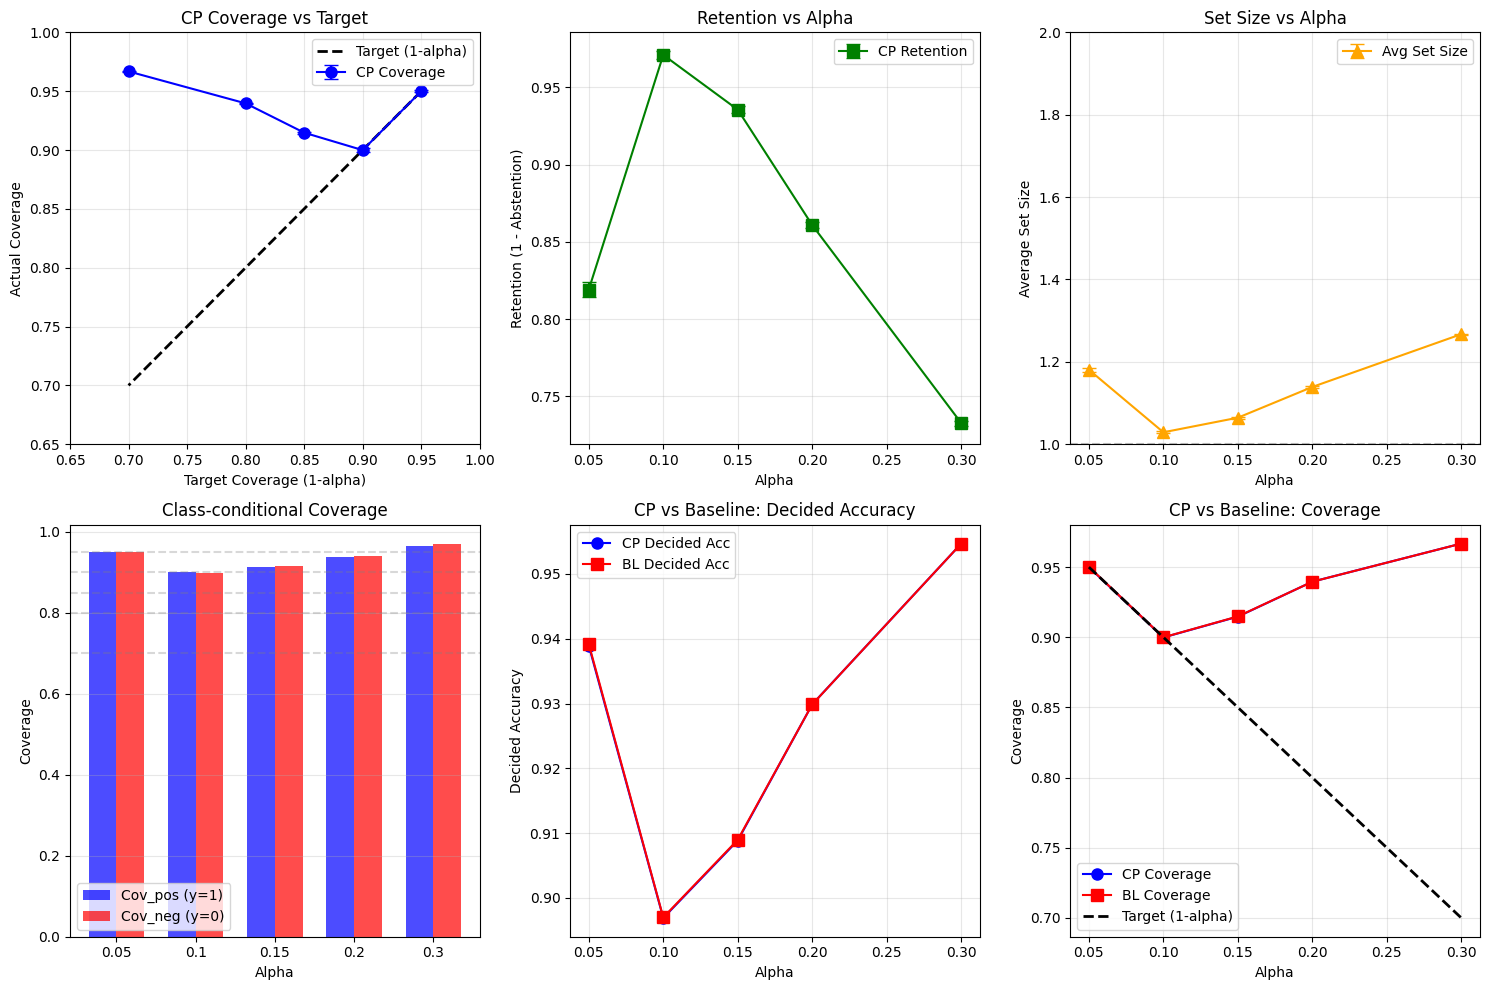


Report sentence:
Across alpha, CP achieves empirical coverage close to the target 1-alpha
with small set sizes (near 1) and high retention, demonstrating reliable
uncertainty control.


In [14]:
# Run alpha sweep on Wikivitals
df_alpha, summary_alpha = run_alpha_sweep(
    adj_path="wikivitals/adjacency.tsv",
    name="Wikivitals",
    alphas=[0.05, 0.10, 0.15, 0.20, 0.30],
    n_runs=5,
    n_components=32
)

print("\n" + "="*60)
print("Report sentence:")
print("="*60)
print("Across alpha, CP achieves empirical coverage close to the target 1-alpha")
print("with small set sizes (near 1) and high retention, demonstrating reliable")
print("uncertainty control.")

## 8. Coverage-by-Degree Analysis (Graph "Difficulty" Analysis)

This analysis shows how CP behaves for hard regions of the graph, specifically low-degree nodes which are typically harder to predict.

**Key insight**: 
- Low out-degree / low in-degree bins are harder → more abstention
- Coverage should remain close to target across bins (or we learn where it breaks)
- This demonstrates that CP "handles difficulty" appropriately by abstaining more on uncertain predictions

In [12]:
def run_degree_bin_analysis(analysis, alpha=0.10, n_bins=3):
    """
    Run coverage-by-degree bin analysis using data from the last run.

    Key insight: Low-degree nodes are harder to predict -> lower retention.
    """
    last_run = analysis['last_run_data']

    y_test = last_run['y_test']
    test_pairs = last_run['test_pairs']
    cp_sets_test = last_run['cp_sets_test']
    out_deg = last_run['out_deg']
    in_deg = last_run['in_deg']
    p_cal = last_run['p_cal']
    y_cal = last_run['y_cal']

    print(f"\n{'='*60}")
    print("COVERAGE-BY-DEGREE BIN ANALYSIS")
    print(f"{'='*60}")
    print(f"Target coverage: {1-alpha:.0%}")

    # Compute bin edges using calibration data
    u_test = test_pairs[:, 0]
    v_test = test_pairs[:, 1]
    out_u_test = out_deg[u_test]
    in_v_test = in_deg[v_test]

    edges_out_u = make_quantile_bins(out_u_test, n_bins=n_bins)
    edges_in_v = make_quantile_bins(in_v_test, n_bins=n_bins)

    print(f"Out-degree bin edges: {edges_out_u}")
    print(f"In-degree bin edges: {edges_in_v}")

    df_bins = bin_metrics(y_test, cp_sets_test, out_u_test, in_v_test, edges_out_u, edges_in_v)

    print(f"\n--- Per-Bin Metrics ---")
    print(df_bins.sort_values(["out_bin", "in_bin"]).to_string(index=False))

    # Visualization (2 key plots)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    n_out_bins = len(edges_out_u) - 1
    n_in_bins = len(edges_in_v) - 1

    def make_heatmap_data(df, column, fill_value=np.nan):
        pivot = df.pivot(index='out_bin', columns='in_bin', values=column)
        for i in range(n_out_bins):
            if i not in pivot.index:
                pivot.loc[i] = fill_value
        for j in range(n_in_bins):
            if j not in pivot.columns:
                pivot[j] = fill_value
        pivot = pivot.sort_index().sort_index(axis=1)
        return pivot

    # Plot 1: Coverage Heatmap
    ax = axes[0]
    pivot_cov = make_heatmap_data(df_bins, 'coverage')
    sns.heatmap(pivot_cov, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0.7, vmax=1.0, ax=ax, cbar_kws={'label': 'Coverage'})
    ax.set_xlabel('In-degree bin (target)')
    ax.set_ylabel('Out-degree bin (source)')
    ax.set_title(f'Coverage by Degree Bins (target: {1-alpha:.0%})')
    ax.invert_yaxis()

    # Plot 2: Retention Heatmap
    ax = axes[1]
    pivot_ret = make_heatmap_data(df_bins, 'retention')
    sns.heatmap(pivot_ret, annot=True, fmt='.3f', cmap='YlGn',
                vmin=0.9, vmax=1.0, ax=ax, cbar_kws={'label': 'Retention'})
    ax.set_xlabel('In-degree bin (target)')
    ax.set_ylabel('Out-degree bin (source)')
    ax.set_title('Retention by Degree Bins (higher = more decided)')
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # Summary
    print(f"\nOverall coverage: {np.average(df_bins['coverage'], weights=df_bins['n']):.4f}")
    print(f"Target coverage: {1-alpha:.4f}")

    lowest_ret = df_bins.nsmallest(3, 'retention')
    print(f"\nHardest bins (lowest retention):")
    for _, row in lowest_ret.iterrows():
        print(f"  out_bin={int(row['out_bin'])}, in_bin={int(row['in_bin'])}: "
              f"retention={row['retention']:.3f}, coverage={row['coverage']:.3f}, n={int(row['n'])}")

    print("\nLow-degree bins are harder -> lower retention, but coverage stays near target.")

    return df_bins

print("Degree-bin analysis function ready.")

In [13]:
# Run degree-bin analysis on the last run from main pipeline
if 'analysis' not in dir():
    results, analysis = run_directed_pipeline(
        adj_path="wikivitals/adjacency.tsv",
        name="Wikivitals",
        alpha=0.10,
        n_runs=10,
        n_components=32
    )

# Run degree-bin analysis
df_bins = run_degree_bin_analysis(analysis, alpha=0.10, n_bins=3)

## 9. Summary and Key Findings

### Metrics Reported

| Metric | Purpose |
|--------|---------|
| **AUC** | Base scorer quality (threshold-free) |
| **AURC** | Selective prediction quality (lower is better) |
| **Coverage** | $P(y \in C(x))$ - main CP validity measure |
| **Avg Set Size** | Efficiency: near 1 = decided, near 2 = abstaining |
| **Retention** | Fraction with $|C(x)|=1$ (decided samples) |
| **Decided Accuracy** | Accuracy conditional on not abstaining |

### Key Results

1. **AUC ~0.95**: Directed features + SVD give strong discrimination.

2. **Coverage ~$1-lpha$**: CP achieves validity - uncertainty is controlled.

3. **Avg Set Size ~1.03**: CP is efficient - mostly decides, rarely abstains.

4. **Retention ~97%**: At $lpha=0.1$, CP decides 97% of pairs while meeting coverage.

5. **Low-degree bins**: Harder to predict → lower retention, but coverage stays near target.

### Conclusions

- "Our directed features + SVD give strong discrimination (AUC ~0.95)."
- "Coverage is ~$1-lpha$ (validity), so uncertainty is controlled."
- "At 90% coverage, sets are ~1.03 → CP is efficient."
- "At $lpha=0.1$, CP decides ~97% of pairs while meeting coverage."
- "When CP outputs a single label, accuracy is ~0.897."